# Data Loading and Preprocessing

In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #for statistical data visualization
from matplotlib.colors import LinearSegmentedColormap #for custom colormaps
from scipy import stats
from plotly.subplots import make_subplots
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

#plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk') #for larger texts and elements
colors = sns.color_palette("viridis", 5) #creating a palette with 5 colors from viridis

In [ ]:
#loading the dataset from github
url = 'https://raw.githubusercontent.com/Aarchi01/data-visualization-dataset/refs/heads/main/Strawberry_Greenhouse.csv';

df = pd.read_csv(url)
print('dataset:\n', df.head()) #displaying the first 5 rows

dataset:
        EnqueuedTimeUtc deviceId  humidity  temparature  irTemparature
0  16/02/2023 13:41:57  290EC1B        83           14             10
1  16/02/2023 13:41:57  290EF53        83           14             12
2  16/02/2023 13:41:58  290F190        88           13             12
3  16/02/2023 13:41:59  290F39C        84           13             11
4  16/02/2023 13:41:59  290F362        89           12             11


In [ ]:
#exploring the dataset
print('dataset shape:\n', df.shape)
print('dataset info:\n', df.info())
print('dataset description:\n', df.describe())

dataset shape:
 (371079, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371079 entries, 0 to 371078
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   EnqueuedTimeUtc  371079 non-null  object
 1   deviceId         371079 non-null  object
 2   humidity         371079 non-null  int64 
 3   temparature      371079 non-null  int64 
 4   irTemparature    371079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 14.2+ MB
dataset info:
 None
dataset description:
             humidity    temparature  irTemparature
count  371079.000000  371079.000000  371079.000000
mean       70.233212      10.857437      14.718577
std        27.817407       6.505052      15.454556
min         0.000000     -40.000000     -40.000000
25%        69.000000       8.000000       9.000000
50%        80.000000      11.000000      12.000000
75%        86.000000      15.000000      18.000000
max       100.000000      31.000000    

The dataset contains 371,079 records of three important environmental features: Humidity, Temparature and Infrared Temperature (irTeparature).
* The humidity levels range from 0-100% with the mean of 70.2% which shows a high-moisture environment. Most of the values of humidity falls between 69% to 86%, indicating a narrow spread.
* The temperature readings range from -40 to 31 degree celcius, with majority of values between 8 and 15.
* The infrared temperature also ranges from -40 to 59 degrees with a high standard deviation of 15.4%.



In [ ]:
#Convert the timestamp to datetime format
df['EnqueuedTimeUtc'] = pd.to_datetime(df['EnqueuedTimeUtc'], format='%d/%m/%Y %H:%M:%S')
df['date'] = df['EnqueuedTimeUtc'].dt.date
df['hour'] = df['EnqueuedTimeUtc'].dt.hour
df['day_of_week'] = df['EnqueuedTimeUtc'].dt.dayofweek
df['month'] = df['EnqueuedTimeUtc'].dt.month


In [ ]:
#create a derived column for temperature differential
df['temp_diff'] = df['temparature'] - df['irTemparature']

Now, VPD stands for Vapor Pressure Deficit. it is a measure of difference between how much moisture the air can hold at a given temperature.

For growing strawberries in a greenhouse, controlling the VPD is very important for the plants health. Usually, the threshold value for VPD is between 0.4 - 1.2 kilopascal (kPa) during the main growing season.

if the VPD is too low, it would mean that the air is too humid and the plant would not be able to release water vapor and may lead to diseases like powdery mildew.

On the other hand, if the VPD is too high, the air would be too dry due to which the they loose water very quickly, which leads to plant stress and unhealthy, less nutrient fruit.

In [ ]:
def vpd(temp_c, humidity_percent):
  #saturated vapor pressure using temperature
  svp = 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))
  #actual vapor pressure using svp ad humidity
  vp = svp * (humidity_percent / 100)
  #VPD
  vpd = svp - vp
  return vpd

#adding VPD column into the dataset
df['vpd'] = vpd(df['temparature'], df['humidity'])


In [ ]:
print("Dataset Overview:")
print(f"Number of readings: {len(df)}")
print(f"Number of unique devices: {df['deviceId'].nunique()}")
print(f"Time range: {df['EnqueuedTimeUtc'].min()} to {df['EnqueuedTimeUtc'].max()}")
print("\nSummary statistics:")
print(df[['humidity', 'temparature', 'irTemparature', 'temp_diff', 'vpd']].describe())

Dataset Overview:
Number of readings: 371079
Number of unique devices: 14
Time range: 2023-02-16 13:41:57 to 2023-12-22 09:25:57

Summary statistics:
            humidity    temparature  irTemparature     temp_diff  \
count  371079.000000  371079.000000  371079.000000  371079.00000   
mean       70.233212      10.857437      14.718577      -3.86114   
std        27.817407       6.505052      15.454556      16.98870   
min         0.000000     -40.000000     -40.000000     -99.00000   
25%        69.000000       8.000000       9.000000      -1.00000   
50%        80.000000      11.000000      12.000000       0.00000   
75%        86.000000      15.000000      18.000000       1.00000   
max       100.000000      31.000000      59.000000      67.00000   

                 vpd  
count  371079.000000  
mean        0.362953  
std         0.273633  
min         0.000000  
25%         0.179733  
50%         0.270152  
75%         0.545711  
max         2.885284  


# Exploratory Data Analysis

Analyzing distributions...


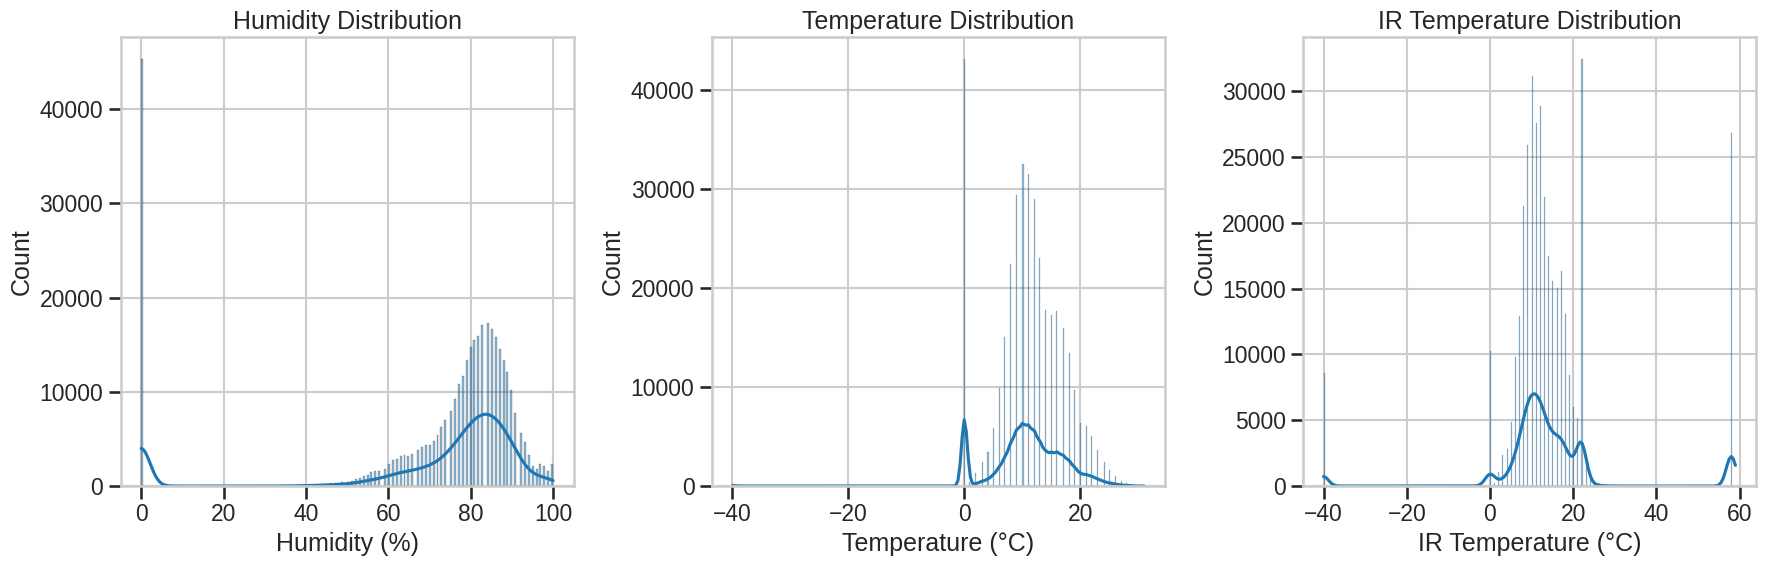

In [ ]:
# Distribution of measurements
print("Analyzing distributions...")
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.histplot(df['humidity'], kde=True, ax=axs[0])
axs[0].set_title('Humidity Distribution')
axs[0].set_xlabel('Humidity (%)')

sns.histplot(df['temparature'], kde=True, ax=axs[1])
axs[1].set_title('Temperature Distribution')
axs[1].set_xlabel('Temperature (°C)')

sns.histplot(df['irTemparature'], kde=True, ax=axs[2])
axs[2].set_title('IR Temperature Distribution')
axs[2].set_xlabel('IR Temperature (°C)')

plt.tight_layout()
plt.savefig('distributions.png', dpi=300)
plt.show()

Analyzing correlations...


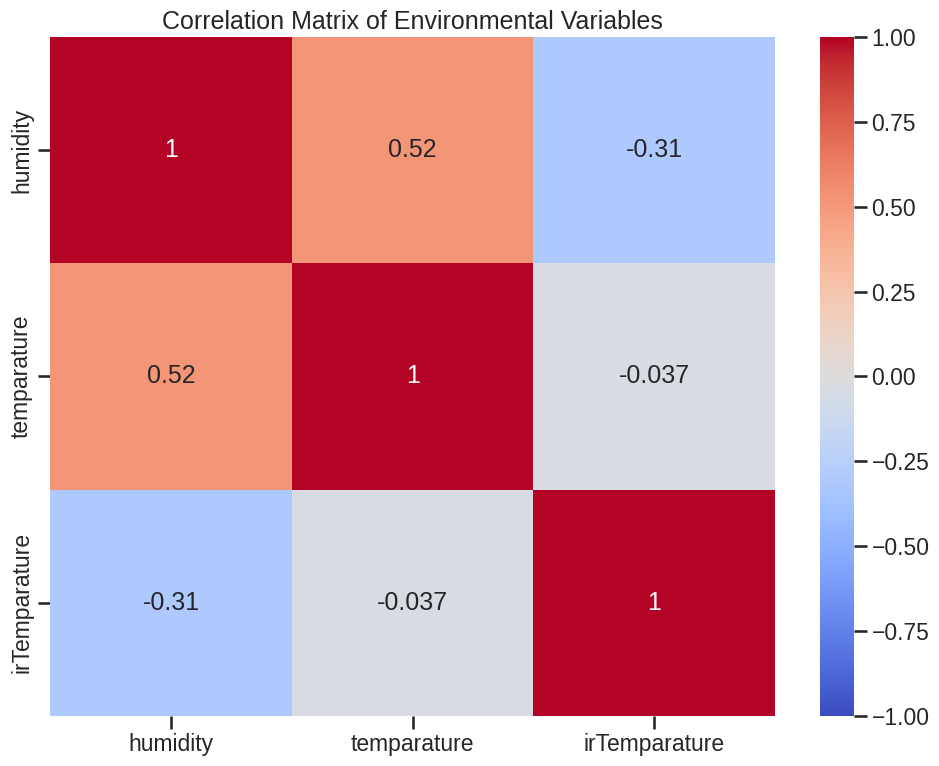

In [ ]:
# Correlation analysis
print("Analyzing correlations...")
correlation_matrix = df[['humidity', 'temparature', 'irTemparature']].corr()
plt.figure(figsize=(10, 8))

#heatmap of correlations with annotations and a diverging color map
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Environmental Variables')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

<Figure size 2000x1000 with 0 Axes>

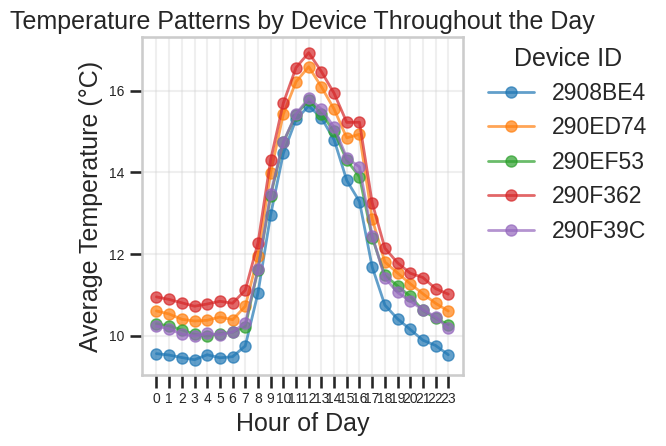

In [ ]:
#Analyze by device (there are 14)
#getting the top 5 devices with most readings
top_devices = df['deviceId'].value_counts().head(5).index

#group data by device and hour and calcuate mean temperature
device_hourly = df[df['deviceId'].isin(top_devices)].groupby(['deviceId', 'hour'])['temparature'].mean().unstack()

plt.figure(figsize=(20, 10))
device_hourly.T.plot(marker='o', linestyle='-', linewidth=2, markersize=8, alpha=0.7)
plt.title('Temperature Patterns by Device Throughout the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Temperature (°C)')
plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(title='Device ID', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.savefig('device_temperature_patterns.png', dpi=300)
plt.show()


# Research Questions

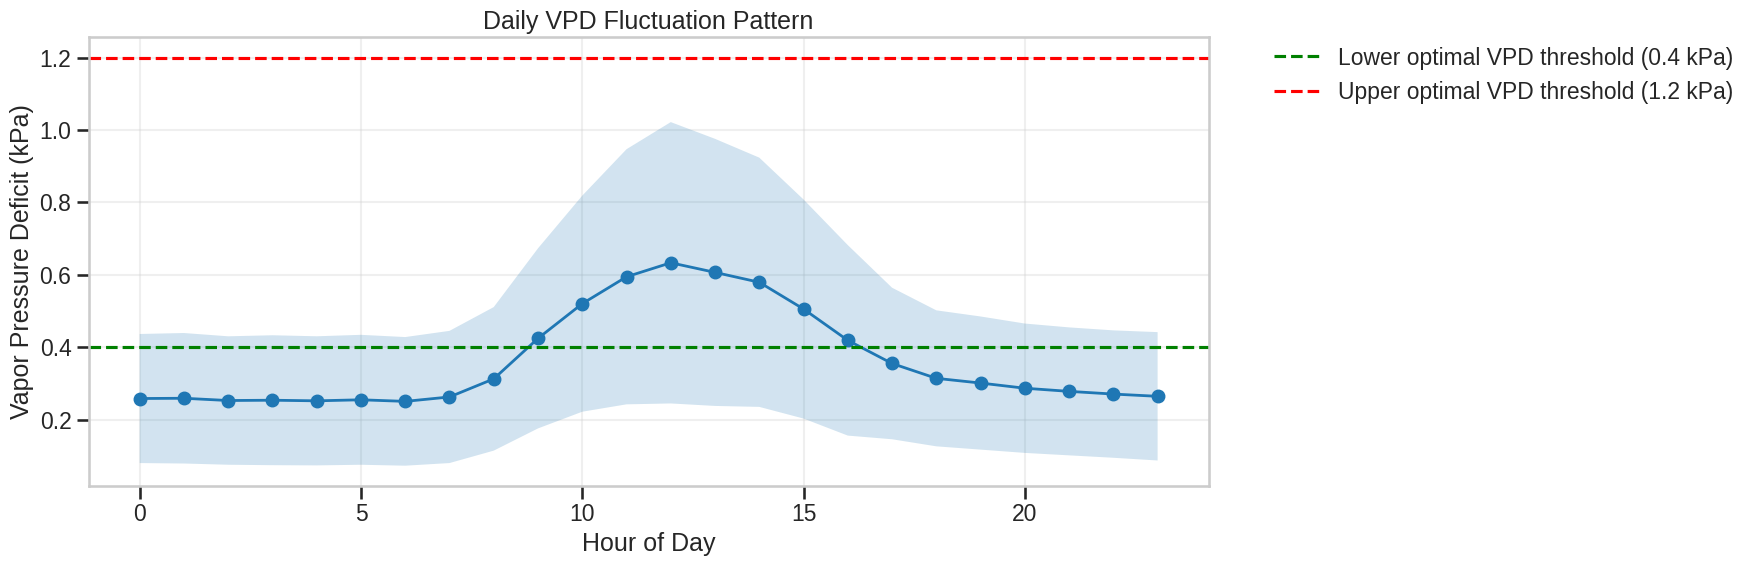

Percentage of time in optimal VPD range (0.4-1.2 kPa): 30.93%

VPD Status Distribution by Hour (%)
vpd_status    Too Low    Optimal  Too High
hour                                      
0           83.118992  16.783580  0.097428
1           82.524147  17.417901  0.057952
2           84.176722  15.790839  0.032438
3           83.538492  16.414931  0.046577
4           84.289795  15.593352  0.116853
5           83.379519  16.536702  0.083779
6           84.031600  15.877744  0.090656
7           82.124236  17.785645  0.090119
8           72.793784  27.206216  0.000000
9           54.242799  44.957409  0.799792
10          43.076724  53.518386  3.404890
11          34.026880  59.763505  6.209615
12          30.051678  60.692091  9.256231
13          32.194464  59.578704  8.226832
14          36.194821  57.174067  6.631112
15          45.516978  50.985629  3.497393
16          59.773787  39.178222  1.047990
17          66.470968  33.400000  0.129032
18          73.729416  26.218922  0.05166

In [ ]:
#Research Question 1: VPD Analysis

# Analyze VPD patterns throughout the day
vpd_hourly = df.groupby('hour')['vpd'].agg(['mean', 'min', 'max', 'std']).reset_index()

# Plot VPD fluctuation throughout the day
plt.figure(figsize=(18, 6))
plt.plot(vpd_hourly['hour'], vpd_hourly['mean'], marker='o', linewidth=2)

#adding shaded area for standard deviation
plt.fill_between(vpd_hourly['hour'], vpd_hourly['mean']-vpd_hourly['std'],
                 vpd_hourly['mean']+vpd_hourly['std'], alpha=0.2)

#adding horizontal reference lines for optimal VPD threshold values
plt.axhline(y=0.4, color='g', linestyle='--', label='Lower optimal VPD threshold (0.4 kPa)')
plt.axhline(y=1.2, color='r', linestyle='--', label='Upper optimal VPD threshold (1.2 kPa)')
plt.xlabel('Hour of Day')
plt.ylabel('Vapor Pressure Deficit (kPa)')
plt.title('Daily VPD Fluctuation Pattern')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('vpd_fluctuation.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate percentage of time in optimal VPD range
optimal_vpd_mask = (df['vpd'] >= 0.4) & (df['vpd'] <= 1.2)
percent_optimal = optimal_vpd_mask.mean() * 100
print(f"Percentage of time in optimal VPD range (0.4-1.2 kPa): {percent_optimal:.2f}%")

# Identify periods with suboptimal VPD conditions
df['vpd_status'] = pd.cut(df['vpd'],
                            bins=[-float('inf'), 0.4, 1.2, float('inf')],
                            labels=['Too Low', 'Optimal', 'Too High'])

# Summarize VPD status by hour for management recommendations
vpd_status_by_hour = pd.crosstab(df['hour'], df['vpd_status'], normalize='index') * 100
print("\nVPD Status Distribution by Hour (%)")
print(vpd_status_by_hour)

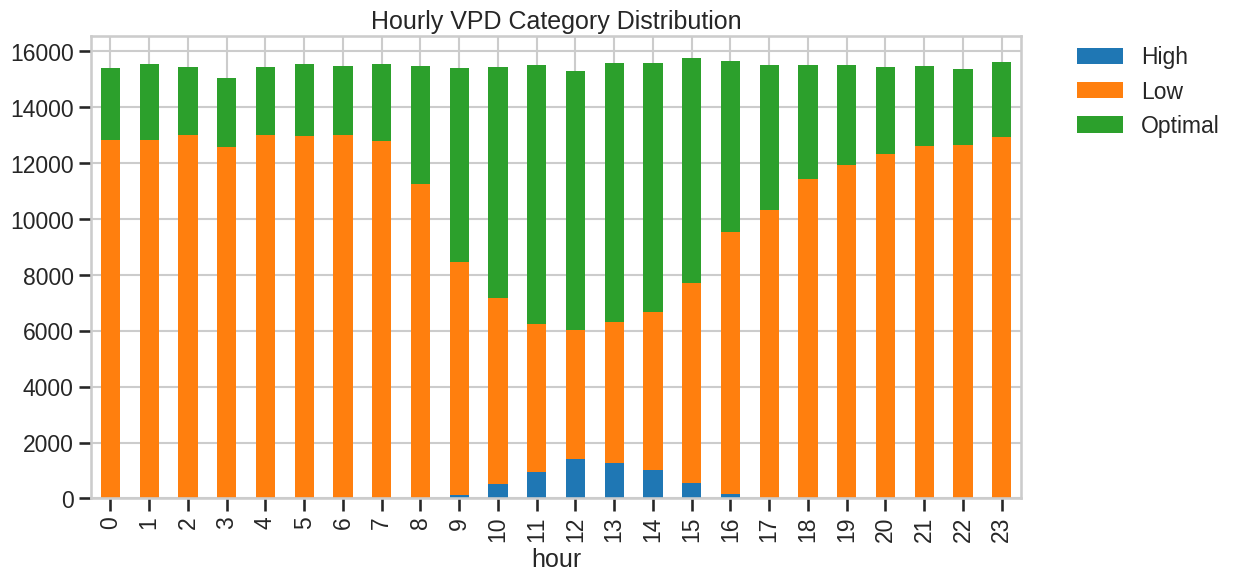

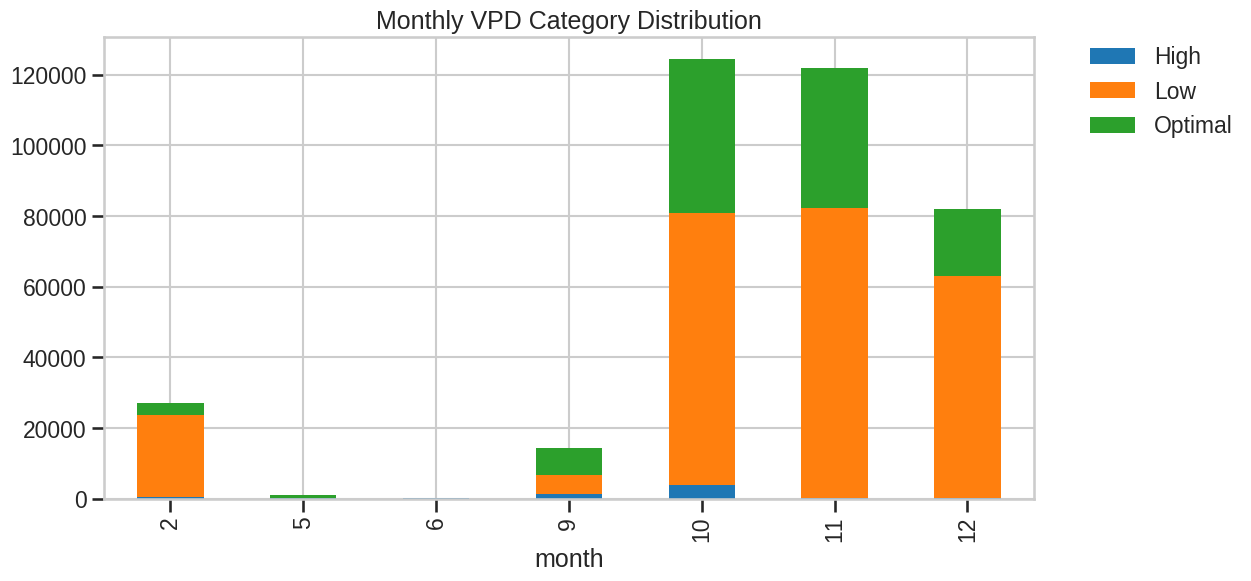

In [ ]:
#define a function to classify VPD into categories for seasonal patterns
def classify_vpd(v):
    if v < 0.4:
        return 'Low'
    elif v <= 1.2:
        return 'Optimal'
    else:
        return 'High'

df['VPD_Category'] = df['vpd'].apply(classify_vpd)

vpd_hourly = df.groupby(['hour', 'VPD_Category']).size().unstack(fill_value=0) #count records in each category by hour
vpd_hourly.plot(kind='bar', stacked=True, figsize=(12, 6), title='Hourly VPD Category Distribution')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig('hourly_vpd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

monthly_vpd = df.groupby(['month', 'VPD_Category']).size().unstack(fill_value=0) #count records in each category by month
monthly_vpd.plot(kind='bar', stacked=True, figsize=(12, 6), title='Monthly VPD Category Distribution')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.savefig('monthly_vpd_changes.png', dpi=300, bbox_inches='tight')
plt.show()

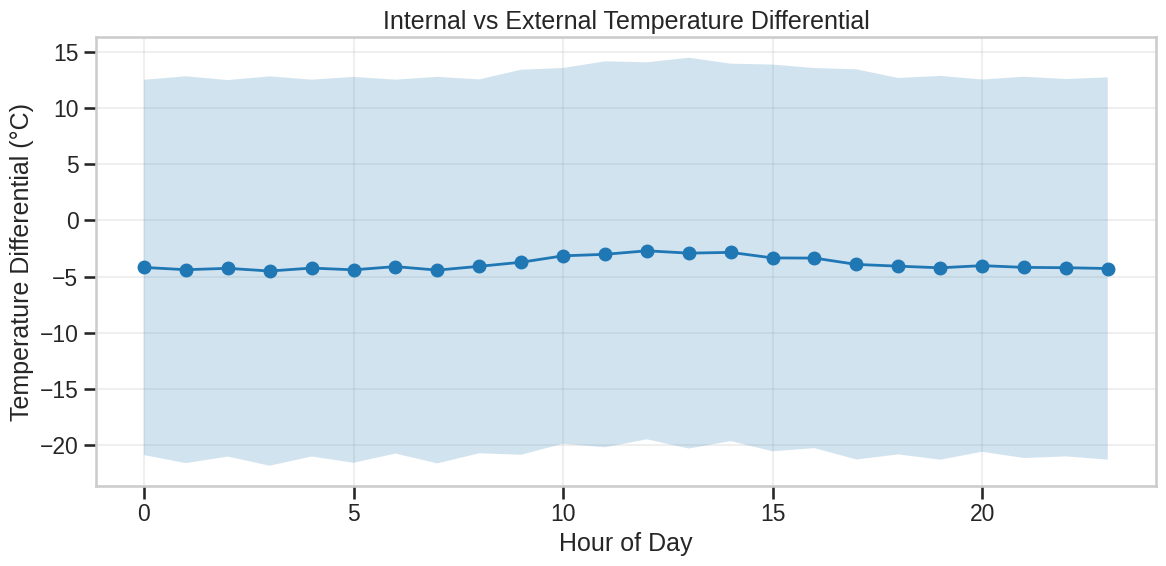

In [ ]:
#research question 2: Temperature differential analysis
# Analyze temperature differential patterns
temp_diff_hourly = df.groupby('hour')['temp_diff'].agg(['mean', 'min', 'max', 'std']).reset_index()

# Plot temperature differential throughout the day
plt.figure(figsize=(12, 6))
plt.plot(temp_diff_hourly['hour'], temp_diff_hourly['mean'], marker='o', linewidth=2)

#adding shaded area for standard deviation for better understanding of the variations
plt.fill_between(temp_diff_hourly['hour'], temp_diff_hourly['mean']-temp_diff_hourly['std'],
                 temp_diff_hourly['mean']+temp_diff_hourly['std'], alpha=0.2)
plt.xlabel('Hour of Day')
plt.ylabel('Temperature Differential (°C)')
plt.title('Internal vs External Temperature Differential')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('temperature_differential.png', dpi=300, bbox_inches='tight')
plt.show()


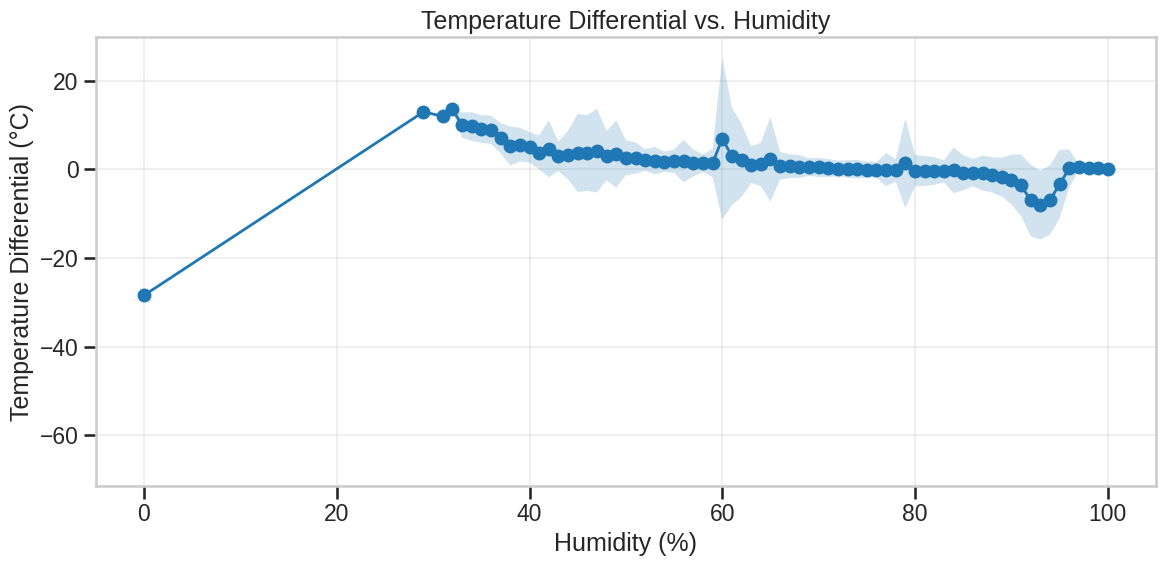

In [ ]:
#plotting a line plot of temperature differential by humidity
temp_diff_by_humidity = df.groupby('humidity')['temp_diff'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(12, 6))
plt.plot(temp_diff_by_humidity['humidity'], temp_diff_by_humidity['mean'], marker='o', linewidth=2)
plt.fill_between(temp_diff_by_humidity['humidity'],
                 temp_diff_by_humidity['mean'] - temp_diff_by_humidity['std'],
                 temp_diff_by_humidity['mean'] + temp_diff_by_humidity['std'],
                 alpha=0.2)
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature Differential (°C)')
plt.title('Temperature Differential vs. Humidity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('temp_diff_vs_humidity.png', dpi=300, bbox_inches='tight')
plt.show()

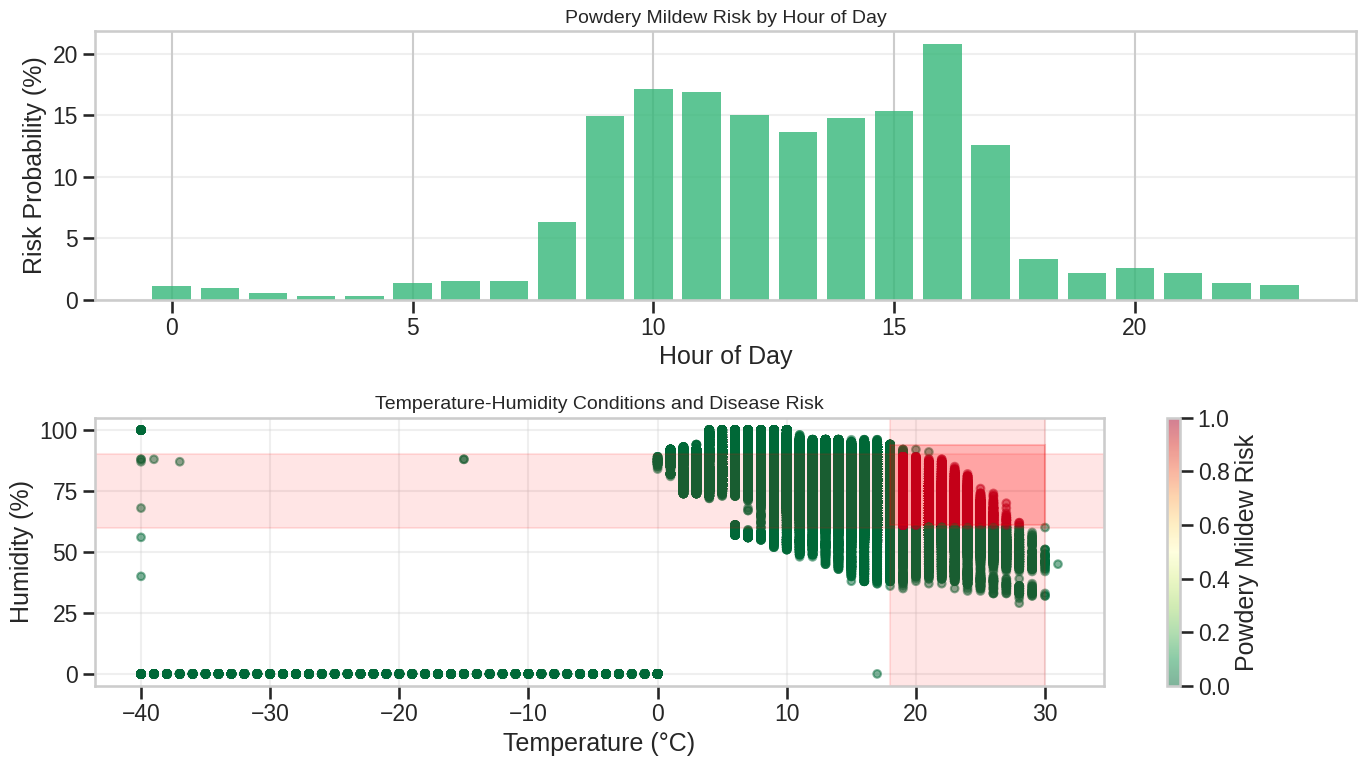

In [ ]:
#research question 3: disease risk analysis
# For Powdery mildew: High risk when 60% < humidity < 90% and 18°C < temp < 30°C
plt.figure(figsize=(14, 8))

# Define powdery mildew risk conditions
df['powdery_mildew_risk'] = ((df['humidity'] > 60) &
                              (df['humidity'] < 90) &
                              (df['temparature'] > 18) &
                              (df['temparature'] < 30)).astype(int)

# Risk by hour bar chart
plt.subplot(2, 1, 1)
risk_by_hour = df.groupby('hour')['powdery_mildew_risk'].mean() * 100
plt.bar(risk_by_hour.index, risk_by_hour.values, color=colors[3], alpha=0.8)
plt.title('Powdery Mildew Risk by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Risk Probability (%)')
plt.savefig('PM_risk_by_hour.png', dpi=300, bbox_inches='tight')
plt.grid(True, alpha=0.3, axis='y')

# Risk conditions scatter plot
plt.subplot(2, 1, 2)
x = df['temparature']
y = df['humidity']
plt.scatter(x, y, c=df['powdery_mildew_risk'], cmap='RdYlGn_r', alpha=0.5, s=30)
plt.colorbar(label='Powdery Mildew Risk')

# Add risk zone box with shaded area
plt.axvspan(18, 30, alpha=0.1, color='red')  #vertical risk zone (temperature)
plt.axhspan(60, 90, alpha=0.1, color='red')  #horizontal risk zone (humidity)

#intersection of the two zones (high-risk area)
plt.axvspan(18, 30, ymin=60/100, ymax=90/100, alpha=0.2, color='red', label='Risk Zone')

plt.title('Temperature-Humidity Conditions and Disease Risk', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('disease_risk.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Summary statistics for key metrics
print("\nSummary Statistics:")
print(f"Average Temperature: {df['temparature'].mean():.1f}°C")
print(f"Average Humidity: {df['humidity'].mean():.1f}%")
print(f"Average VPD: {df['vpd'].mean():.2f} kPa")
print(f"Temperature differential: {df['temp_diff'].mean():.1f}°C")
print(f"Percentage of time in optimal VPD range: {(df['vpd_status']=='Optimal').mean()*100:.1f}%")
print(f"Percentage of time with powdery mildew risk: {df['powdery_mildew_risk'].mean()*100:.1f}%")


Summary Statistics:
Average Temperature: 10.9°C
Average Humidity: 70.2%
Average VPD: 0.36 kPa
Temperature differential: -3.9°C
Percentage of time in optimal VPD range: 30.9%
Percentage of time with powdery mildew risk: 7.0%


In conclusion,

climate analysis results show moderate growing conditions with an average temperature of 10.9°C and humidity of 70.2%. The VPD averages at 0.36kPa, indication low transpiration pressure. There was notable temperature differential of -3.9°C. Only 30.9% of the monitering period was able to maintain optimal VPD ranges for plant growth, while powdery mildew risk was present but limited to 7% of the time.

These values suggests that adjustments to certain environmetal conditions may benefit to increase the suitable growing time for strawberries in a greenhouse facility.